<a href="https://colab.research.google.com/github/Dworlock11/Exoplanet-Prediction-and-Analysis/blob/main/Exoplanet%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Overview**

This project builds machine learning models to predict exoplanet type and planet mass using a real-world exoplanet dataset. Multiple models, including logistic/linear regression, decision trees, and random forests, are trained with hyperparameter tuning and cross-validation to ensure robust performance. Feature importance is analyzed to identify the most influential factors driving predictions. The workflow emphasizes both predictive accuracy and interpretability, culminating in the selection of the best model for each task. This project demonstrates a comprehensive, production-ready approach to applied machine learning on scientific data.

# **Import Statements**

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (make_scorer, confusion_matrix, ConfusionMatrixDisplay, classification_report, mean_absolute_error,
                             root_mean_squared_error)
from sklearn.inspection import permutation_importance
from sklearn.exceptions import ConvergenceWarning
from warnings import simplefilter
from preprocessing import remove_cols, log_space, huber_loss, mini_terran, mass_dist, remove_null_entries
from modeling import (data_spliting, optimizing_training_predicting, classification_evaluation, feature_importance, regression_scoring,
                      regression_plots)

# **Exploratory Data Analysis and Preprocessing**

The data from the exoplanet catlog contained in the Excel sheet is read into a DataFrame.

In [19]:
df = pd.read_excel("Exoplanet Catalog.xlsx")
pd.set_option("display.max_columns", None)
df

,P_NAME,P_STATUS,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_YEAR,P_UPDATED,P_PERIOD,P_PERIOD_ERROR_MIN,P_PERIOD_ERROR_MAX,P_SEMI_MAJOR_AXIS,P_SEMI_MAJOR_AXIS_ERROR_MIN,P_SEMI_MAJOR_AXIS_ERROR_MAX,P_ECCENTRICITY,P_ECCENTRICITY_ERROR_MIN,P_ECCENTRICITY_ERROR_MAX,P_INCLINATION,P_INCLINATION_ERROR_MIN,P_INCLINATION_ERROR_MAX,P_OMEGA,P_OMEGA_ERROR_MIN,P_OMEGA_ERROR_MAX,P_TPERI,P_TPERI_ERROR_MIN,P_TPERI_ERROR_MAX,P_ANGULAR_DISTANCE,P_IMPACT_PARAMETER,P_IMPACT_PARAMETER_ERROR_MIN,P_IMPACT_PARAMETER_ERROR_MAX,P_TEMP_MEASURED,P_GEO_ALBEDO,P_GEO_ALBEDO_ERROR_MIN,P_GEO_ALBEDO_ERROR_MAX,P_DETECTION,P_DETECTION_MASS,P_DETECTION_RADIUS,P_ALT_NAMES,P_ATMOSPHERE,S_NAME,S_RA,S_DEC,S_MAG,S_DISTANCE,S_DISTANCE_ERROR_MIN,S_DISTANCE_ERROR_MAX,S_METALLICITY,S_METALLICITY_ERROR_MIN,S_METALLICITY_ERROR_MAX,S_MASS,S_MASS_ERROR_MIN,S_MASS_ERROR_MAX,S_RADIUS,S_RADIUS_ERROR_MIN,S_RADIUS_ERROR_MAX,S_TYPE,S_AGE,S_AGE_ERROR_MIN,S_AGE_ERROR_MAX,S_TEMPERATURE,S_TEMPERATURE_ERROR_MIN,S_TEMPERATURE_ERROR_MAX,S_DISC,S_MAGNETIC_FIELD,S_LOG_G,S_ALT_NAMES,P_ESCAPE,P_POTENTIAL,P_GRAVITY,P_DENSITY,P_HILL_SPHERE,P_DISTANCE,P_PERIASTRON,P_APASTRON,P_DISTANCE_EFF,P_FLUX,P_FLUX_MIN,P_FLUX_MAX,P_TEMP_EQUIL,P_TEMP_EQUIL_MIN,P_TEMP_EQUIL_MAX,P_TYPE,S_RADIUS_EST,S_TYPE_TEMP,S_RA_H,S_RA_T,S_DEC_T,S_LUMINOSITY,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,S_HZ_CON0_MIN,S_HZ_CON0_MAX,S_HZ_CON1_MIN,S_HZ_CON1_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_SEMI_MAJOR_AXIS_EST
0,11 Com b,3.0,6165.86330,-476.74200,476.74200,NaN,NaN,NaN,2007.0,2014-05-14,326.030000,-0.320,0.320,1.29000,-0.050,0.050,0.231,-0.005,0.005,NaN,NaN,NaN,94.8,-1.5,1.5,2452899.6,-1.6,1.6,13.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Radial Velocity,NaN,NaN,NaN,NaN,11 Com,185.179280,17.792868,4.740,93.37,-1.92,1.92,-0.35,-0.09,0.09,2.70,-0.300,0.300,19.000000,-2.000,2.000,K0 III,NaN,NaN,NaN,4742.0,-100.0,100.0,NaN,NaN,2.31,"HD 107383, HIP 60202",NaN,NaN,NaN,NaN,0.130671,1.324418,0.99201,1.58799,1.298759,101.011410,64.855456,166.191940,799.44963,722.98875,914.73942,Jovian,19.000000,K,12.345286,12 20 43.0286,+17 47 34.3248,163.546800,10.132812,24.763411,12.834754,23.477907,13.586847,23.477907,12.390643,23.477907,34.529063,0.476460,0.642400,0.0,0.0,Hot,0.0,0.083813,Coma Berenices,Com,Berenice's Hair,12.082709,6165.863300,1.29000
1,11 UMi b,3.0,4684.78480,-794.57001,794.57001,NaN,NaN,NaN,2009.0,2018-09-06,516.219970,-3.200,3.200,1.53000,-0.070,0.070,0.080,-0.030,0.030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Radial Velocity,NaN,NaN,NaN,NaN,11 UMi,229.274540,71.823898,5.016,125.72,-1.97,1.97,-0.02,NaN,NaN,2.78,-0.690,0.690,29.790000,-2.840,2.840,K4 III,NaN,NaN,NaN,4213.0,-46.0,46.0,NaN,NaN,1.93,"HD 136726, HIP 74793",NaN,NaN,NaN,NaN,0.167551,1.534896,1.40760,1.65240,1.531227,107.351180,91.741348,126.426170,819.07569,788.47184,854.28770,Jovian,29.790000,K,15.284970,15 17 05.8915,+71 49 26.0328,250.492940,12.770059,31.984271,16.175280,30.323783,17.134143,30.323783,15.615215,30.323783,42.732816,0.193891,0.648683,0.0,0.0,Hot,0.0,0.082414,Ursa Minor,UMi,Little Bear,12.229641,4684.784800,1.53000
2,14 And b,3.0,1525.57440,NaN,NaN,NaN,NaN,NaN,2008.0,2014-05-14,185.840000,-0.230,0.230,0.83000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,2452861.4,-1.5,1.5,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Radial Velocity,NaN,NaN,NaN,NaN,14 And,352.822570,39.236198,5.227,75.59,-0.71,0.71,-0.24,-0.03,0.03,2.20,-0.200,0.100,11.000000,-1.000,1.000,G8 III,NaN,NaN,NaN,4813.0,-20.0,20.0,NaN,NaN,2.63,"HD 221345, HIP 116076",NaN,NaN,NaN,NaN,0.073485,0.830000,0.83000,0.83000,0.830000,84.446427,84.446427,84.446427,772.30746,772.30746,772.30746,Jovian,11.000000,G,23.521506,23 31 17.4215,+39 14 10.3128,58.175144,6.025230,14.680087,7.631867,13.918028,8.078404,13.918028,7.367780,13.918028,20.593611,0.502752,0.600010,0.0,0.0,Hot,0.0,0.081917,Andromeda,And,And

Before the data can be used for model development, it needs to be cleaned and analyzed. Firstly, as many of the columns from the dataset contain many null entries, it is best to simply remove them. Therefore, all columns where more than a quarter of the entries are null are removed. Additional feature selection is also conducted, as many of the features are unhelpful for model training, are copies of one another, are highly correlated with one another, or have far too many different values. Below are the numbers of unique values for each categorical feature, with many being removed.

In [20]:
df = remove_cols(df)

Value count per feature:
P_DETECTION - 10
P_TYPE - 6
S_TYPE_TEMP - 7
S_RA_T - 3010
S_DEC_T - 3010
P_TYPE_TEMP - 3
S_CONSTELLATION - 88
S_CONSTELLATION_ENG - 88


To determine the appropriate imputing method for the numerical data, the data is checked for the skew of each feature. Since the features are heavily skewed overall, the median will be chosen. Below is the skew of each column.

In [21]:
np.abs(df.skew(axis=0, numeric_only=True, skipna=True)).sort_values(ascending=False)

,0
P_PERIOD,62.170001
P_FLUX,45.699102
S_MASS_ERROR_MAX,45.649624
S_ABIO_ZONE,39.242821
S_RADIUS_ERROR_MIN,32.113850
S_RADIUS_ERROR_MAX,31.053663
P_PERIASTRON,28.463444
P_SEMI_MAJOR_AXIS_EST,28.395487
P_DISTANCE_EFF,28.376942
P_DISTANCE,28.337572


The distribution of the exoplanet type column is observed.

In [22]:
df["P_TYPE"].value_counts()

,count
P_TYPE,
Jovian,1302
Superterran,1099
Neptunian,898
Terran,673
Subterran,58
Miniterran,1


There is only a single Miniterran planet in the dataset and thus cannot be split between a training and test set. However, if the Miniterran in the data were to have a radius close to that of Subterrans, it would be appropriate to mask it as one, since, astronomically speaking, it wouldn't be too different from the smallest Subterrans discovered. Indeed, the radius is around 0.33 times that of Earth, which isn't too far in value from the smallest Subterran in the dataset. Therefore, the planet is masked as one. After masking, no Miniterrans remain, as shown in the following value count.

In [23]:
df = mini_terran(df)

df["P_TYPE"].value_counts()

Miniterran mass: 0.334
Smallest Subterran mass: 0.404


,count
P_TYPE,
Jovian,1302
Superterran,1099
Neptunian,898
Terran,673
Subterran,59


Now, the distribution of exoplanet mass is observed and graphed.

In [24]:
df["P_MASS_EST"].describe()

,P_MASS_EST
count,4048.000000
mean,323.089993
std,965.084290
min,0.000000
25%,3.628101
50%,7.815324
75%,149.379160
max,17668.059000


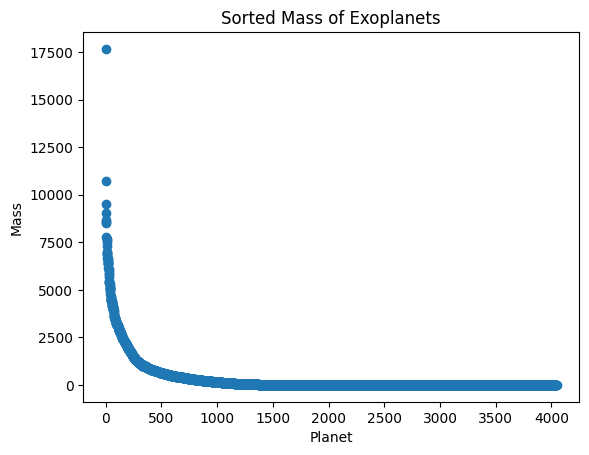

In [25]:
mass_dist(df)

From this distribution, some insights can be found:
*   The median exoplanet seems to be approximately eight times the mass of the Earth. A minority of exoplanets is singificantly larger. There will almost certainly be a significant difference between the root mean squared error (RMSE) and mean absolute error (MAE) scores when evaluating the models, since RMSE is more sensitive to outliers.
*   Because the smallest planets and the largest are orders of magnitude apart, it would be appropriate to perform a log transformation on the mass to ensure robust prediction. This engineered feature will be stored in a copy of the dataset and used for regression.
*   Huber loss will be used for hyperparameter tuning and permutation importance in order to balance the majority of small planets with the minority of massive ones.
*   It's not clear what exactly it means for a planet to have a mass of 0.0. Such entries will be removed from the dataset.

In [26]:
huber_scorer = make_scorer(huber_loss, greater_is_better=False, delta=1.0)

df = df[df["P_MASS_EST"] != 0.0]

log_df = log_space(df)

Finally, all rows where the target value is null are removed to prevent errors.

In [27]:
df = remove_null_entries(df, "P_TYPE")
log_df = remove_null_entries(log_df, "Log_Mass")

Number of null values in P_TYPE: 1
Number of null values after removal: 0
Number of null values in Log_Mass: 1
Number of null values after removal: 0


With data preprocessing and analysis complete, model development can begin.

# **Exoplanet Type Prediction**

The classification models will be trained first. The data is split into the training and testing data. The target is stratified by the exoplanet type to make sure that a proportional number of each type of planet is present in both the training set and the test set.

In [28]:
X, y, X_train, X_test, y_train, y_test, num_features, cat_features, num_col_names, cat_col_names = data_spliting(df, stratify=True, target="P_TYPE")

## Logistic Regression

The logistic regression model will be developed first. The data pipeline is created, including data imputing, standardizing, and encoding. KFolds object is created for cross-validation. Additionally, the parameter distribution for the hyperparameter C is created to ensure robust regularization.

In [29]:
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

linear_cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", feature_name_combiner="concat"))
])

log_preprocessor = ColumnTransformer([
    ("num_transformer", num_transformer, num_col_names),
    ("linear_cat_transformer", linear_cat_transformer, cat_col_names)
])

log_pipe = Pipeline([
    ("log_preprocessor", log_preprocessor),
    ("log_reg", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        max_iter=300
    ))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=9)

param_dist = {
    "log_reg__C": np.logspace(-3, 3, 15),
}

The hyperparameter is tuned, the model is fitted to the data, and the target is predicted. The models perform well overall with little variation between folds.

In [30]:
best_model, y_pred = optimizing_training_predicting(log_pipe, param_dist, kf, None, X_train, y_train, X_test)

Best Parameters:

C : 372.7593720314938

Best CV Score: 0.9525 ± 0.0045


The model is evaluated with a classification report, depicting useful metrics such as accuracy and the F1 score. Additionally, a confusion matrix is generated to illustrate these findings. The model performs very well overall, with most metrics being greater than 0.90. The exception being Subterrans, which performed significantly worse than the other exoplanet types, likely due to a much smaller number of entries in the dataset causing bias.

Classification Report:

              precision    recall  f1-score   support

      Jovian       0.98      0.97      0.98       260
   Neptunian       0.94      0.94      0.94       180
   Subterran       0.58      0.58      0.58        12
 Superterran       0.96      0.97      0.96       220
      Terran       0.94      0.94      0.94       135

    accuracy                           0.95       807
   macro avg       0.88      0.88      0.88       807
weighted avg       0.95      0.95      0.95       807

Confusion Matrix:



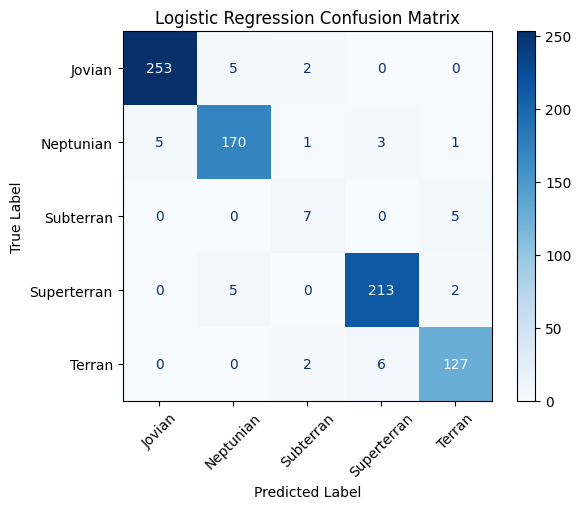

In [31]:
classification_evaluation(y_test, y_pred, model_name="Logistic Regression")

Permutation importance is used to find the importance of each feature. It will be used across all models for standardized results. The test set must be manually transformed with all preprocessing steps before implementing permutation to match the number of columns present after feature encoding. Apparently, the most important feature for predicting planet type is radius. This would make sense, as Jovian planets are significantly larger in size than Terrans, for example. Planet radius demonstrates a clear divide in different types and therefore acts as a strong predictor of it.

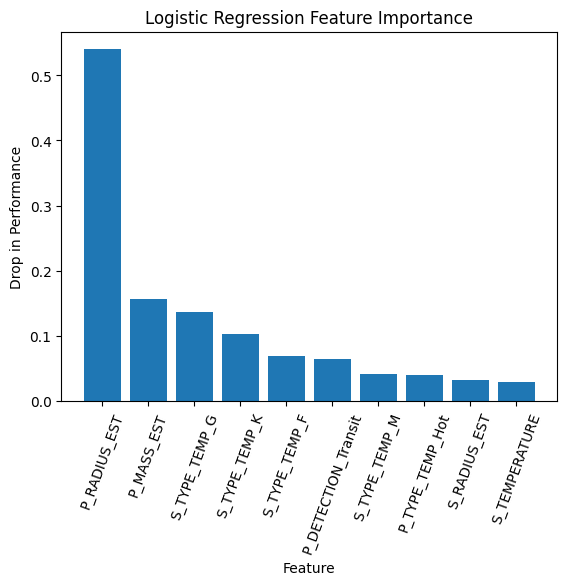

In [32]:
feature_importance(best_model, "log_preprocessor", "log_reg", X_test, y_test, None, model_name="Logistic Regression")

## Polynomial Logistic Regression

Now, polynomial features are added to see if they will make a significant difference.

A new preprocessor and pipeline are created to accomodate polynomial features.

In [33]:
# Build polynomial transformer
poly_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

# Combine transformers
poly_log_preprocessor = ColumnTransformer([
    ("poly_transformer", poly_transformer, num_col_names),
    ("linear_cat_transformer", linear_cat_transformer, cat_col_names)
])

poly_log_pipe = Pipeline([
    ("poly_log_preprocessor", poly_log_preprocessor),
    ("log_reg", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        max_iter=300
    ))
])

param_dist = {
    "log_reg__C": np.logspace(-3, 3, 15),
}

The pipeline is created and hyperparameter tuning is implemented.

Hyperparameters are optimized, the model is fitted to the data, and the target is predicted.

In [34]:
best_model, y_pred = optimizing_training_predicting(poly_log_pipe, param_dist, kf, None, X_train, y_train, X_test)

Best Parameters:

C : 51.794746792312125

Best CV Score: 0.9311 ± 0.0081


The model is evaluated with a classification report, depicting useful metrics such as accuracy and the F1 score. Additionally, a confusion matrix is generated to illustrate these findings.

Classification Report:

              precision    recall  f1-score   support

      Jovian       0.99      0.96      0.97       260
   Neptunian       0.93      0.94      0.94       180
   Subterran       0.62      0.67      0.64        12
 Superterran       0.94      0.97      0.95       220
      Terran       0.94      0.92      0.93       135

    accuracy                           0.95       807
   macro avg       0.88      0.89      0.89       807
weighted avg       0.95      0.95      0.95       807

Confusion Matrix:



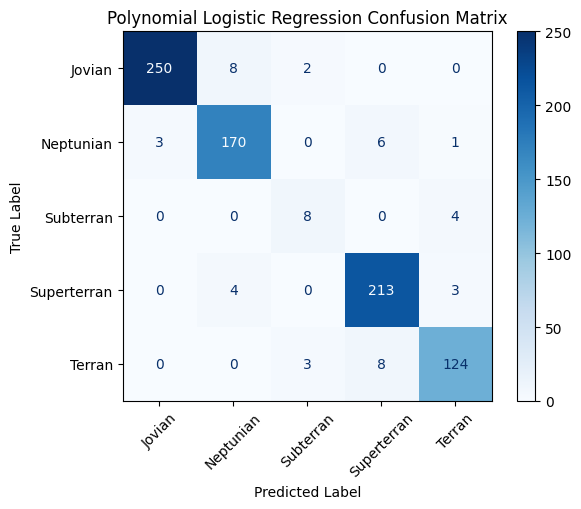

In [35]:
classification_evaluation(y_test, y_pred, model_name="Polynomial Logistic Regression")

The model performs around the same as without polynomial features. However, the time necessary to train is significantly longer. Therefore, there seems to be little reason to include polynomial features.

Feature importance is ignored, as most of the features are simply engineered polynomial features, giving little legitimate insight.

## Decision Tree

Now, a decision tree model will be trained following the same process.

A new categorical transformer is created using ordinal encoding, which is suitable for tree-based models and better than one-hot encoding, since it doesn't create many sparse features.

In [36]:
# Create categorical transformer for tree models
tree_cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# Combine transformers
tree_preprocessor = ColumnTransformer([
    ("num_transformer", num_transformer, num_col_names),
    ("tree_cat_transformer", tree_cat_transformer, cat_col_names)
])

# Create pipeline
tree_clas_pipe = Pipeline([
    ("tree_preprocessor", tree_preprocessor),
    ("dec_tree", DecisionTreeClassifier())
])

# Parameter distribution
param_dist = {
    "dec_tree__max_depth": [None, 2, 5, 10, 20],
    "dec_tree__min_samples_split": [2, 5, 10, 20, 50],
    "dec_tree__min_samples_leaf": [1, 2, 5, 10, 20],
    "dec_tree__max_features": ["sqrt", "log2", None],
}

Optimization, training, and predicting are carried out.

In [37]:
best_model, y_pred = optimizing_training_predicting(tree_clas_pipe, param_dist, kf, None, X_train, y_train, X_test)

Best Parameters:

min_samples_split : 2
min_samples_leaf : 5
max_features : None
max_depth : 10

Best CV Score: 0.9953 ± 0.0017


The model is tested and evaluated.

Classification Report:

              precision    recall  f1-score   support

      Jovian       0.98      0.99      0.99       260
   Neptunian       0.98      0.97      0.98       180
   Subterran       1.00      1.00      1.00        12
 Superterran       1.00      1.00      1.00       220
      Terran       1.00      1.00      1.00       135

    accuracy                           0.99       807
   macro avg       0.99      0.99      0.99       807
weighted avg       0.99      0.99      0.99       807

Confusion Matrix:



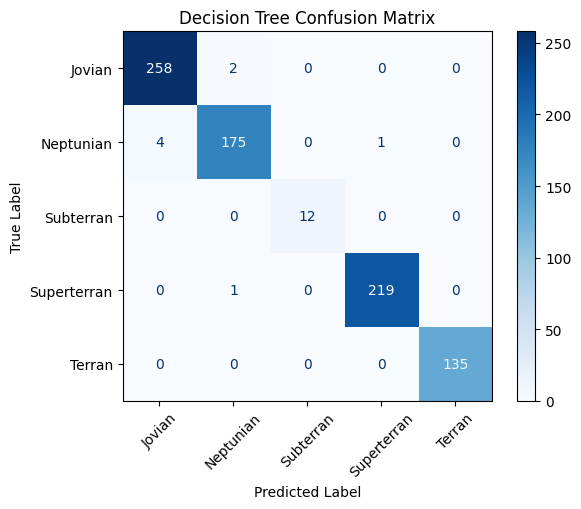

In [38]:
classification_evaluation(y_test, y_pred, "Decision Tree")

The metrics are notably better than those from the logistic regression model, especially for Subterrans. Perhaps decision trees are better suited for multiclass classification, even with little data.

Permutation is once again used to discover feature importance.

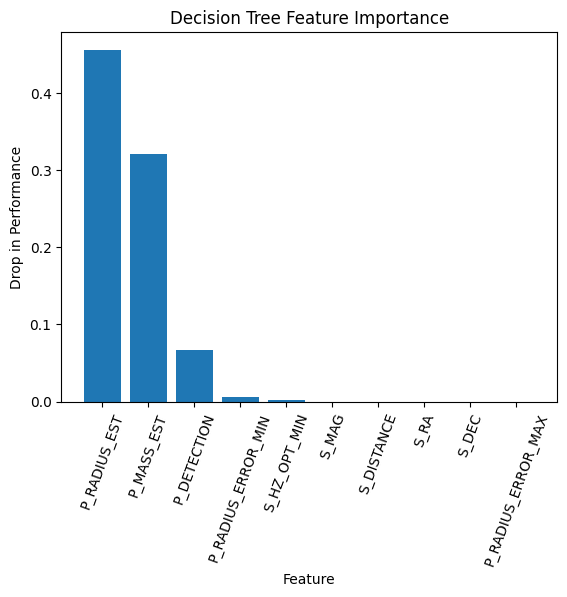

In [39]:
feature_importance(best_model, "tree_preprocessor", "dec_tree", X_test, y_test, None, "Decision Tree")

In comparison to the logistic regression model, mass in a decision tree is a more significant predictor of exoplanet type. This may be because the logistic regression models found it more difficult to determine the importance of mass due to the nonlinear distribution of the feature. With ordinary logistic regression, only linear decision boundaries are found.

## Random Forest

Now, a random forest model will be trained.

The pipeline is created and hyperparameter tuning is implemented, testing ranges of values for the major hyperparameters.

In [40]:
forest_clas_pipe = Pipeline([
    ("tree_preprocessor", tree_preprocessor),
    ("rand_for", RandomForestClassifier())
])

param_dist = {
    "rand_for__n_estimators": [200, 400, 600, 800],
    "rand_for__max_depth": [None, 5, 10, 20, 40],
    "rand_for__min_samples_split": [2, 5, 10, 20],
    "rand_for__min_samples_leaf": [1, 2, 5, 10],
    "rand_for__max_features": ["sqrt", "log2", None],
    "rand_for__bootstrap": [True, False],
}

The model is trained and hyperparameter values are shown.

In [41]:
best_model, y_pred = optimizing_training_predicting(forest_clas_pipe, param_dist, kf, None, X_train, y_train, X_test)

Best Parameters:

n_estimators : 600
min_samples_split : 5
min_samples_leaf : 2
max_features : None
max_depth : 40
bootstrap : True

Best CV Score: 0.9922 ± 0.0026


The model is again evaluated with a classification report and confusion matrix.

Classification Report:

              precision    recall  f1-score   support

      Jovian       0.98      0.99      0.99       260
   Neptunian       0.98      0.97      0.98       180
   Subterran       1.00      1.00      1.00        12
 Superterran       1.00      1.00      1.00       220
      Terran       1.00      1.00      1.00       135

    accuracy                           0.99       807
   macro avg       0.99      0.99      0.99       807
weighted avg       0.99      0.99      0.99       807

Confusion Matrix:



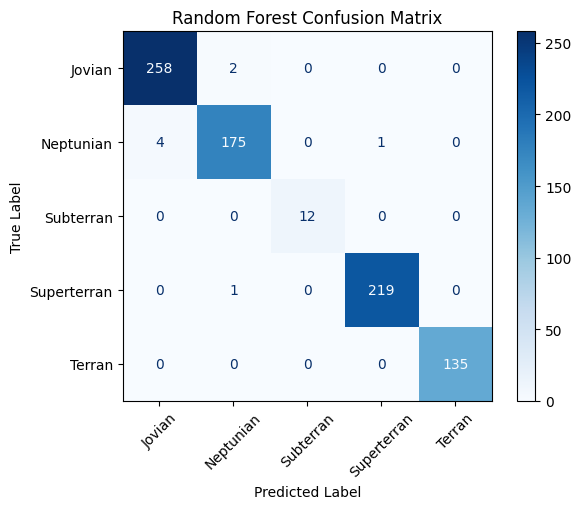

In [42]:
classification_evaluation(y_test, y_pred, "Random Forest")

The metrics are around the same as those for the decision tree model. However, it takes much longer to fit, making random forests apparently unnecessary for this task.

Permutation is once again used to discover feature importance.

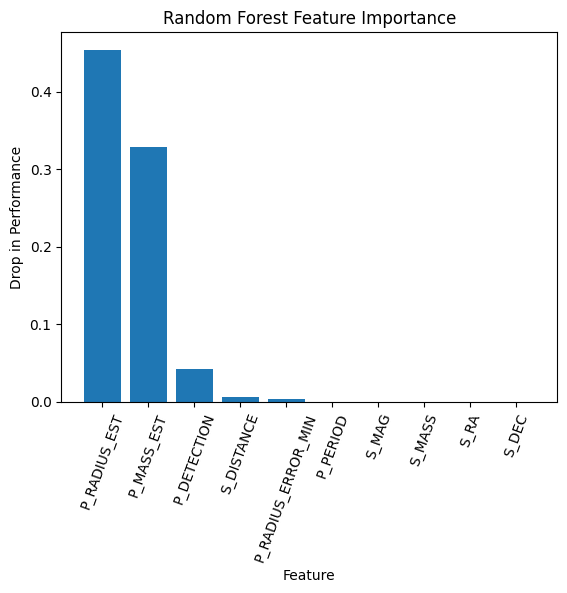

In [43]:
feature_importance(best_model, "tree_preprocessor", "rand_for", X_test, y_test, None, "Random Forest")

The results are similar to those from the decision tree model.

This concludes the development of the classfication models.

# **Exoplanet Mass Prediction**

Now, regression models will be created to predict exoplanet mass.

## Ridge Regression

A simple linear regression model is a good starting point. Specifically, Ridge will be chosen over standard linear regression to be able to use regularization.

The data is split into the features and the target and then into training and testing data. The numerical and categorical features are identified.

In [44]:
X, y, X_train, X_test, y_train, y_test, num_features, cat_features, num_col_names, cat_col_names = data_spliting(log_df, stratify=False, target="Log_Mass")

The transformers used for the logistic regression model can be reused. A new pipeline and parameter distribution are created and a new KFolds object that doesn't stratify the target, since the target is not categorical.

In [45]:
# Combine transformers
ridge_preprocessor = ColumnTransformer([
    ("num_transformer", num_transformer, num_col_names),
    ("linear_cat_transformer", linear_cat_transformer, cat_col_names)
])

ridge_pipe = Pipeline([
    ("ridge_preprocessor", ridge_preprocessor),
    ("ridge", Ridge())
])

kf = KFold(n_splits=5, shuffle=True, random_state=9)

param_dist = {
    "ridge__alpha": np.logspace(-4, 4)
}

Hyperparameter optimization, fitting, and predicting are conducted.

In [46]:
best_model, y_pred = optimizing_training_predicting(ridge_pipe, param_dist, kf, huber_scorer, X_train, y_train, X_test)

Best Parameters:

alpha : 1526.4179671752302

Best CV Score: -1252614407.7948 ± 2505228815.3796


RMSE and MAE are used to evaluate the model.

In [47]:
regression_scoring(y_test, y_pred)

MAE factor  : 3.66×
RMSE factor : 45010330.47×


The results aren't promising. To understand why, the array of predicted values is analyzed along with the true values.

In [48]:
y_pred_se = pd.Series(y_pred)

y_pred_se.describe()

,0
count,807.000000
mean,1.562995
std,7.763020
min,0.260055
25%,0.719682
50%,0.946642
75%,2.010783
max,220.658874


In [49]:
y_test_se = y_test.reset_index(drop=True)

y_test_se.describe()

,Log_Mass
count,807.000000
mean,1.260273
std,1.007618
min,-1.719657
25%,0.578587
50%,0.874435
75%,2.090880
max,3.884029


There appears to be a major outlier present in the predicted values. This is further visible in a scatter plot of the actual and predicted values.

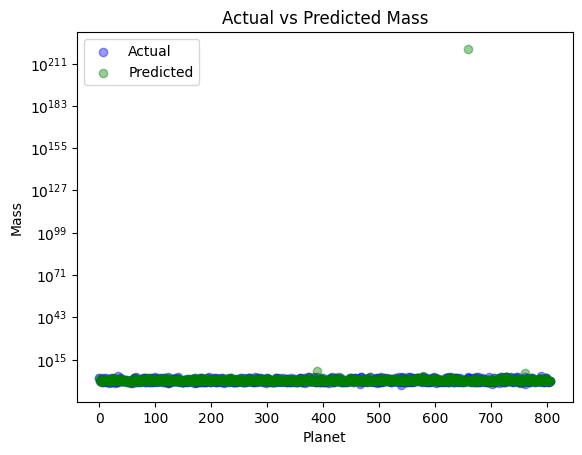

In [50]:
regression_plots(y_test, y_pred)

It appears that one heavily inacurate prediction is causing the metrics to significantly worsen. Therefore, linear regression doesn't seem to be a good model for this task.

## Polynomial Ridge Regression

Perhaps adding polynomial features will improve the results.

A polynomial ridge pipeline is created along with a fitting parameter distribution.

In [51]:
# Create polynomial transformer
poly_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler())
])

# Combine transformers
poly_ridge_preprocessor = ColumnTransformer([
    ("poly_transformer", poly_transformer, num_col_names),
    ("linear_cat_transformer", linear_cat_transformer, cat_col_names)
])

# Create pipeline
poly_ridge_pipe = Pipeline([
    ("poly_ridge_preprocessor", poly_ridge_preprocessor),
    ("ridge", Ridge())
])

# Create parameter distribution
param_dist = {
    "poly_ridge_preprocessor__poly_transformer__poly__degree" : [2, 3],
    "ridge__alpha" : np.logspace(-4, 4)
}

The pipeline is created and the alpha value along with the polynomial degree are tuned.

In [52]:
best_model, y_pred = optimizing_training_predicting(poly_ridge_pipe, param_dist, kf, huber_scorer, X_train, y_train, X_test)

Best Parameters:

alpha : 3237.45754281764
poly_transformer__poly__degree : 2

Best CV Score: -380156911953278468096.0000 ± 760313823906556936192.0000


RMSE and MAE are used to evaluate the model.

In [53]:
regression_scoring(y_test, y_pred)

MAE factor  : 90100003.22×
RMSE factor : 785605796452345664379290322034733201129824937865441569220040608656447361036159426672534914858169593742575526999555941049148796095045396546903943169114604559826963869042785960187408316050036693633393212204655803629568.00×


The results are even worse than without polynomial features. In fact, the RMSE score is unimaginably bad. The predicted values are again analyzed to learn why.

In [54]:
y_pred_se = pd.Series(y_pred)

y_pred_se.describe()

,0
count,807.000000
mean,-6.410771
std,215.808964
min,-6128.851052
25%,0.640829
50%,0.910099
75%,2.108988
max,6.474707


In [55]:
y_test_se.describe()

,Log_Mass
count,807.000000
mean,1.260273
std,1.007618
min,-1.719657
25%,0.578587
50%,0.874435
75%,2.090880
max,3.884029


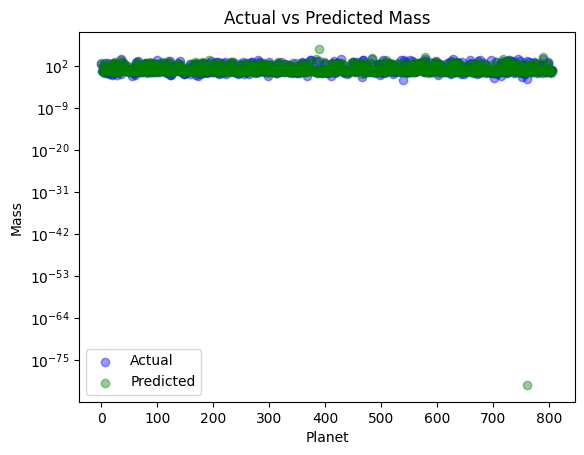

In [56]:
regression_plots(y_test, y_pred)

As before, there is a single inacurate value bringing the model down. With or without polynomial features, linear regression is inadequate.

## Decision Tree Regressor

Now, a decision tree is created, hopefully bearing better results. A suitable pipeline is created.

In [57]:
# Combine numerical and categorical transformers
tree_preprocessor = ColumnTransformer([
    ("num_transformer", num_transformer, num_col_names),
    ("tree_cat_transformer", tree_cat_transformer, cat_col_names)
])

tree_reg_pipe = Pipeline([
    ("tree_preprocessor", tree_preprocessor),
    ("dec_tree", DecisionTreeRegressor())
])

param_dist = {
    "dec_tree__max_depth": [None, 3, 5, 10, 20],
    "dec_tree__min_samples_split": [2, 5, 10, 20, 50],
    "dec_tree__min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "dec_tree__max_features": [None, "sqrt", "log2"]
}

The model is trained and hyperparameter values are displayed.

In [58]:
best_model, y_pred = optimizing_training_predicting(tree_reg_pipe, param_dist, kf, huber_scorer, X_train, y_train, X_test)

Best Parameters:

min_samples_split : 50
min_samples_leaf : 2
max_features : None
max_depth : 20

Best CV Score: -0.0257 ± 0.0029


As before, RMSE and MAE are used to evaluate the model.

In [59]:
regression_scoring(y_test, y_pred)

MAE factor  : 1.24×
RMSE factor : 1.67×


The results point to a strong model. Real exoplanet masses often have 30-100% observational uncertainty, so a 24% error factor is very good. This is also evident in a scatter plot.

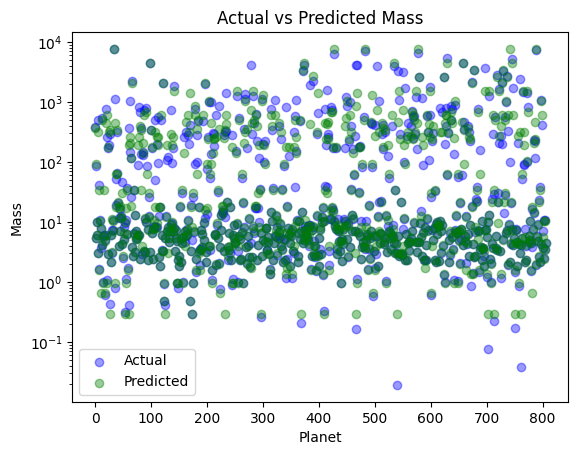

In [60]:
regression_plots(y_test, y_pred)

Permutation is used to find important features.

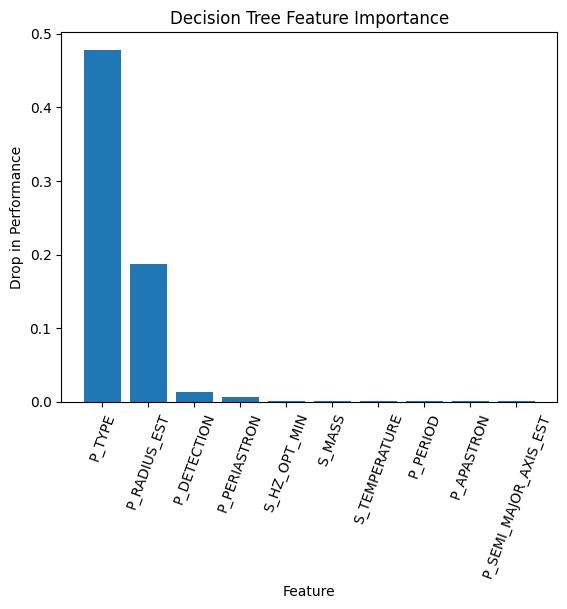

In [61]:
feature_importance(best_model, "tree_preprocessor", "dec_tree", X_test, y_test, huber_scorer, "Decision Tree")

By far the most important features are the planet's type and radius. These findings make sense; mass and radius are often correlated and a Jovian planet will certainly have a greater mass than a Terran one.

## Random Forest Regressor

Perhaps a random forest will be even better for prediction. As usual, the pipeline is created.

In [62]:
forest_reg_pipe = Pipeline([
    ("tree_preprocessor", tree_preprocessor),
    ("rand_for", RandomForestRegressor())
])

param_dist = {
    "rand_for__n_estimators": [200, 300, 500, 800],
    "rand_for__max_depth": [None, 5, 10, 20, 40],
    "rand_for__min_samples_split": [2, 5, 10, 20],
    "rand_for__min_samples_leaf": [1, 2, 5, 10, 20],
    "rand_for__max_features": ["sqrt", "log2", None],
    "rand_for__bootstrap": [True, False]
}

Again, the model is trained and tuned hyperparameter values are shown.

In [63]:
best_model, y_pred = optimizing_training_predicting(forest_reg_pipe, param_dist, kf, huber_scorer, X_train, y_train, X_test)

Best Parameters:

n_estimators : 300
min_samples_split : 20
min_samples_leaf : 2
max_features : None
max_depth : 40
bootstrap : True

Best CV Score: -0.0200 ± 0.0026


RMSE and MAE are used to evaluate the model as usual.

In [64]:
regression_scoring(y_test, y_pred)

MAE factor  : 1.20×
RMSE factor : 1.56×


The model performs slightly better than the decision tree model, but takes much more time to train. These results are similar to those from the classification tree models.

A plot is generated as before to underscore these findings.

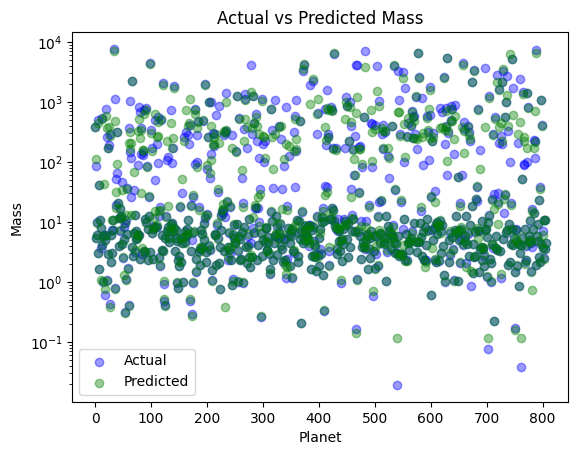

In [65]:
regression_plots(y_test, y_pred)

The predicted and actual values are relatively close together, implying little error in prediction.

Feature importance is analyzed.

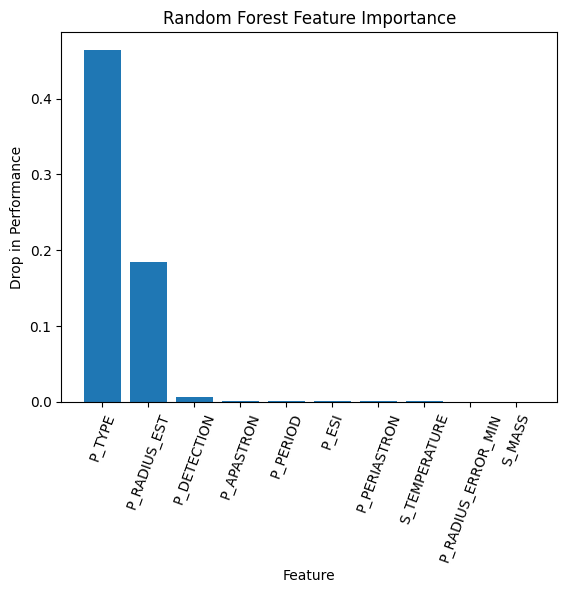

In [66]:
feature_importance(best_model, "tree_preprocessor", "rand_for", X_test, y_test, huber_scorer, "Random Forest")

The results are similar to those from the decision tree model.

# **Conclusion**

To conclude, significant insights can be drawn from this analysis. Firstly, decision trees seem to be the all-around best models for both classification of exoplanet type and of mass. Random forests produce slightly better results but take longer to train. The tree models may have outperformed the linear models due to not being restricted to following a linear structure. This was especially important for predicting exoplanet mass, which doesn't follow a linear pattern. Another important discovery is that the most important features for classifying exoplanets were their radius and mass. The most important features for predicting a planet's mass were its type and radius. Therefore, exoplanet type, radius, and mass seem to be highly correlated. This has scientific precedent, as Jovian and Neptunian planets are known to have greater masses and sizes than Subterrans, for example. One can presume that these are important characteristics used by scientists when creating models with exoplanet data.

# **Copyright**

The data used in this project was taken from the exoplanet catalog found here: https://www.kaggle.com/datasets/chandrimad31/phl-exoplanet-catalog?resource=download.

I claim no ownership of the data. All rights reserved to the rightful owners.